In [40]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv('../data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### EDA 

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [43]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [44]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [45]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [46]:
df['Sex'].value_counts()

Sex
male      690
female    310
Name: count, dtype: int64

In [47]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [48]:
df.isnull().sum() 

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

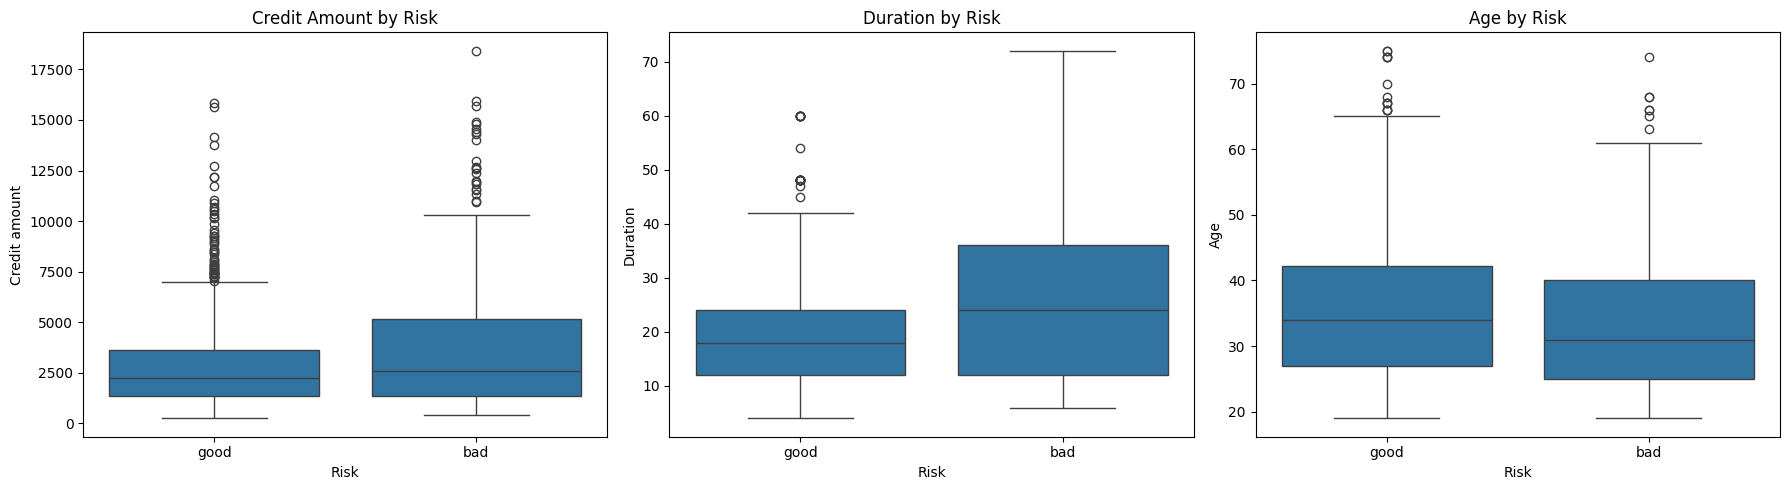

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Risk', y='Credit amount', ax=axes[0])
axes[0].set_title('Credit Amount by Risk')
sns.boxplot(data=df, x='Risk', y='Duration', ax=axes[1])
axes[1].set_title('Duration by Risk')
sns.boxplot(data=df, x='Risk', y='Age', ax=axes[2])
axes[2].set_title('Age by Risk')

plt.tight_layout()
plt.show()

### Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---- 1. Handle missing values ----
# Missing here likely means "doesn't have this account type", not "unknown"
# so we fill with a new category instead of mode/mean
df['Saving accounts'] = df['Saving accounts'].fillna('none')
df['Checking account'] = df['Checking account'].fillna('none')

# ---- 2. Encode the target variable ----
# good = 0, bad = 1  (bad = the "positive" class we care about detecting)
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

# ---- 3. Encode categorical features ----
# 'Sex' and 'Housing' are binary/simple categories -> Label Encoding is fine
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])          # male/female -> 0/1
df['Housing'] = le.fit_transform(df['Housing'])  # own/rent/free -> 0/1/2

# 'Saving accounts', 'Checking account', 'Purpose' have more categories
# with no natural order -> One-Hot Encoding avoids implying false ranking
df = pd.get_dummies(df, columns=['Saving accounts', 'Checking account', 'Purpose'], drop_first=True)

# ---- 4. Separate features (X) and target (y) ----
X = df.drop('Risk', axis=1)
y = df['Risk']

# ---- 5. Train-test split ----
# stratify=y ensures both train and test sets keep the same 70/30 good/bad ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 6. Scale numeric features ----
# Logistic Regression is sensitive to feature scale; Decision Trees/RF are not,
# but scaling numeric columns doesn't hurt them either, so we do it once for all models
scaler = StandardScaler()
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train shape: (800, 20)
Test shape: (200, 20)
Risk
0    0.7
1    0.3
Name: proportion, dtype: float64


### Model training block

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (bad)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression     0.705   0.505882  0.716667  0.593103  0.763095
Decision Tree           0.720   0.538462  0.466667  0.500000  0.647619
Random Forest           0.750   0.647059  0.366667  0.468085  0.752619


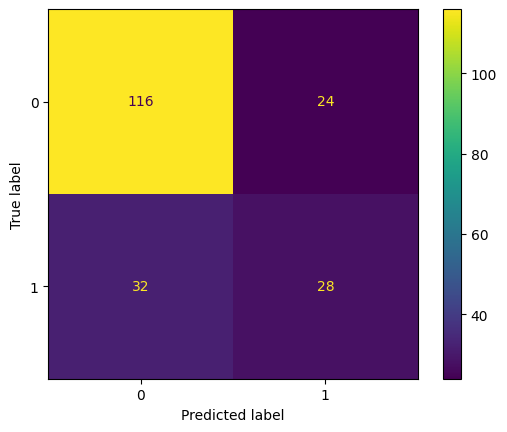

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(models['Decision Tree'], X_test, y_test)

                        Feature  Coefficient
11        Checking account_none    -1.660415
9          Saving accounts_rich    -1.007215
7          Saving accounts_none    -0.803652
15            Purpose_education     0.793163
18              Purpose_repairs     0.583680
12        Checking account_rich    -0.542570
19      Purpose_vacation/others    -0.479442
5                      Duration     0.443942
1                           Sex    -0.441324
17             Purpose_radio/TV    -0.406617
8    Saving accounts_quite rich    -0.406476
10    Checking account_moderate    -0.301304
3                       Housing     0.199695
14  Purpose_domestic appliances    -0.139156
16  Purpose_furniture/equipment    -0.071149
4                 Credit amount     0.070273
0                           Age    -0.037428
6      Saving accounts_moderate    -0.024958
13                  Purpose_car    -0.007730
2                           Job     0.003767


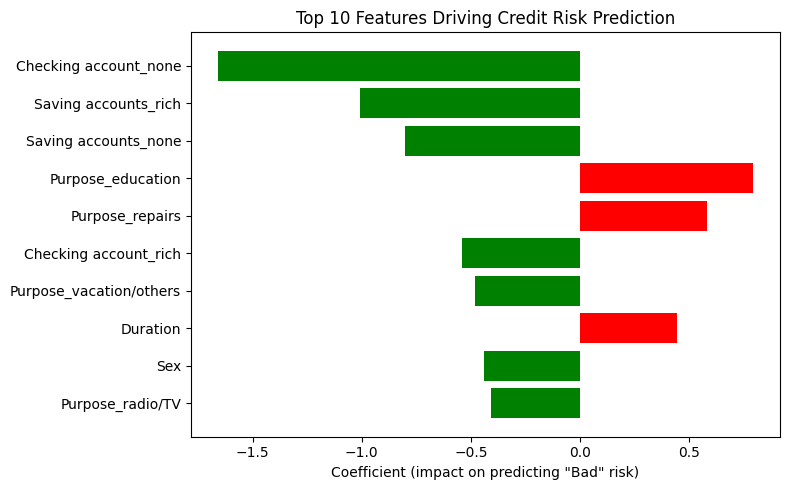

In [53]:
# balanced Logistic Regression model
log_reg = models['Logistic Regression']

# Pair feature names with their coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

# Visualize top 10
import matplotlib.pyplot as plt
top10 = coef_df.head(10)
plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Coefficient'], color=['red' if c > 0 else 'green' for c in top10['Coefficient']])
plt.xlabel('Coefficient (impact on predicting "Bad" risk)')
plt.title('Top 10 Features Driving Credit Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Saving the model

In [54]:
import joblib

joblib.dump(log_reg, '../models/credit_scoring_logreg.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
